In [1]:
%matplotlib inline

import random

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power

import matplotlib.pylab as plt

import warnings
warnings.filterwarnings("ignore")

## Resampling

In [2]:
# Load web page data and display the first 5 rows
session_times = pd.read_csv('web_page_data.csv')
session_times.head()

,Page,Time
0,Page A,0.21
1,Page B,2.53
2,Page A,0.35
3,Page B,0.71
4,Page A,0.67


In [3]:
# Multiply the Time column by 100
session_times['Time'] = 100*session_times['Time']
session_times.head()

,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0


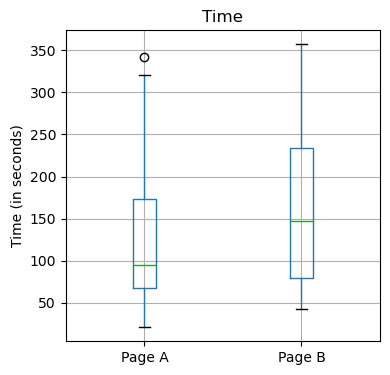

In [4]:
# Create a boxplot of the Page and Time fields
ax = session_times.boxplot(by="Page", column="Time", figsize=(4,4))
ax.set_xlabel("")
ax.set_ylabel("Time (in seconds)")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [5]:
# Calculate the average time on Page A
mean_a = session_times[session_times["Page"]=="Page A"]["Time"].mean()

# Calculate the average time on Page b
mean_b = session_times[session_times["Page"]=="Page B"]["Time"].mean()

# Calculate the difference between the 2 averages
print(mean_b-mean_a)

35.66666666666667


In [6]:
# Permutation test example with stickiness
def perm_fun(x, nA, nB):
    """ 
    x: series
    nA: number of rows associated with A value
    nB: number of rows associated with B value
    """

    # Calculate the total number of rows
    n = nA + nB

    # Sample nB (15) rows from  the total n (36)
    idx_B = set(random.sample(range(n), nB))

    # Set the A records to be total records minus the B records
    idx_A = set(range(n)) - idx_B

    # Return the average of B less the average of A
    return x.loc[list(idx_B)].mean() - x.iloc[list(idx_A)].mean()

# Determine the number of rows that Page = Page A
nA = session_times[session_times["Page"]=="Page A"].shape[0] #21

# Determine the number of rows that Page = Page B
nB = session_times[session_times["Page"]=="Page B"].shape[0] #15
print(perm_fun(session_times["Time"], nA, nB))

-25.933333333333337


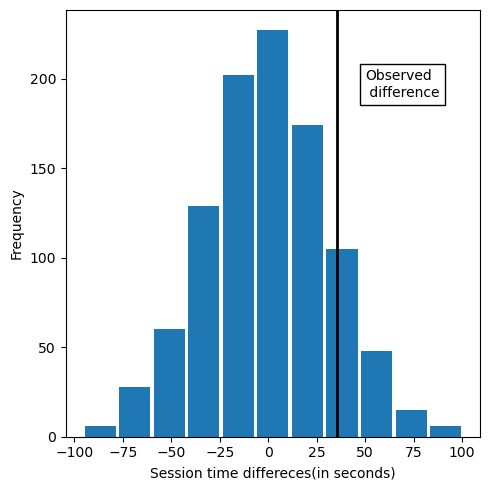

In [7]:
random.seed(1)

# Get 1000 itterations of the average B -average A samples above
perm_diffs = [perm_fun(session_times["Time"], nA, nB) for _ in range(1000)]

# PLot the 1000 sample differences and include a vertical line of the actual differences
fix, ax = plt.subplots(figsize=(5,5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=mean_b - mean_a, color="black", lw=2)
ax.text(50,190, "Observed\n difference", bbox={"facecolor":"white"}) 
ax.set_xlabel("Session time differeces(in seconds)")
ax.set_ylabel("Frequency")


plt.tight_layout()
plt.show()

In [8]:
# Convert perm_diffs to numpy array to avoid problems with some Python installations
# Calculate the percentage of same differences that were greater than the actual differences
perm_diffs = np.array(perm_diffs)
print(np.mean(perm_diffs > mean_b - mean_a))

0.121


##### Observations: The observed difference in time between Page A and Page B of 12.1% is not statistically significant 

# Statistical Significance and P-Values

Observed difference: 0.0368%


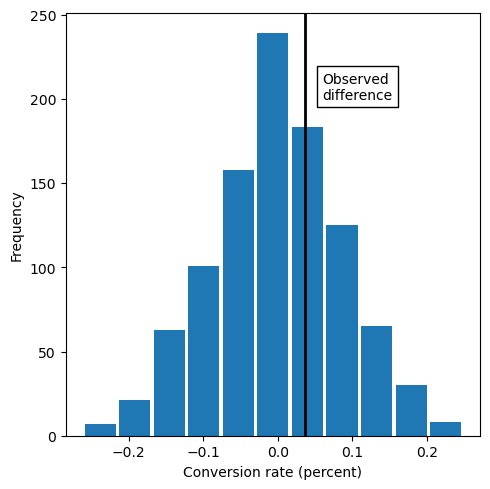

In [9]:
random.seed(1)

# Calculate the observed average difference
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')

# Create a list and fill it with 45945 0 records
conversion = [0] * 45945

# Add 382 rows to the conversion list with a 1
conversion.extend([1] * 382)

# Convert the list to a Series
conversion = pd.Series(conversion)

# Create 1000 sampleaverage differences based on the mean of 1 and 0 sampled values
perm_diffs = [100 * perm_fun(conversion, 23739, 22588) 
              for _ in range(1000)]

# PLot the 1000 sample average difference
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)

# Include a vertical line of the observed difference value calculated first
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
# Calculate the percentage of same differences that were greater than the actual differences
print(np.mean([diff > obs_pct_diff for diff in perm_diffs]))

0.332


##### Observations: The observed difference in time between Page A and Page B of 33.2% is not statistically significant 

## P-Value

In [11]:
survivors = np.array([[200, 23749-200],[182,22588-182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)

print(f"P-value for single sided test: {p_value/2:.4f}")

P-value for single sided test: 0.3513


##### Observation: 35.13% is not statistically significant. This value is similar to the ones obtained in the permutation test above of 33.2%

## t-Tests

In [12]:
# Calculate a t-test for the Page  vs Page B time spent
res = stats.ttest_ind(session_times[session_times["Page"] == "Page A"].Time,
                      session_times[session_times["Page"] == "Page B"].Time,
                      equal_var=False)
print(f"P-value for single sided test: {res.pvalue / 2:.4f}")

P-value for single sided test: 0.1408


The p-value of 14.08 is similar to the 12.1 calculate previously above

In [13]:
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times["Page"]=="Page A"].Time,
    session_times[session_times["Page"]=="Page B"].Time,
    usevar="unequal", alternative="smaller")
print(f"P-value: {pvalue:.4f}")

P-value: 0.1408


# ANOVA

In [14]:
# Load the four session data and display the first 5 rows
four_sessions = pd.read_csv('four_sessions.csv')
four_sessions.head()

,Page,Time
0,Page 1,164
1,Page 2,178
2,Page 3,175
3,Page 4,155
4,Page 1,172


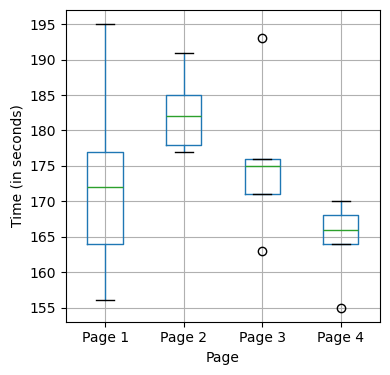

In [15]:
# Create a boxplot by Page and Time
ax = four_sessions.boxplot(by="Page", 
                           column = "Time",
                           figsize=(4,4))
ax.set_xlabel("Page")
ax.set_ylabel("Time (in seconds)")
plt.suptitle("")
plt.title("")
plt.tight_layout()
plt.show()

In [16]:
# Compute a permutation test of the 4 pages
observed_variance = four_sessions.groupby(["Page"]).mean().var()[0]
fsg = four_sessions.groupby("Page").mean().values.ravel()
print("Observed means:", fsg)
print('Variance:', observed_variance)

# Permutation test example with stickiness
def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var()[0]
    
print(perm_test(four_sessions))

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655
1.5600000000000176


##### Observations: The permutation test value varies each time this is run

Pr(Prob) 0.086


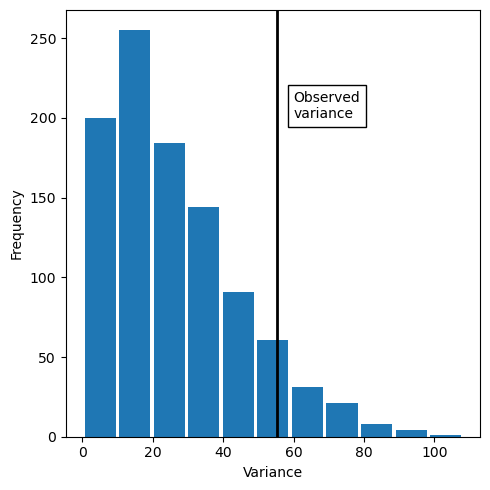

In [17]:

random.seed(1)

perm_variance = [perm_test(four_sessions) for _ in range(1000)]
npm = np.mean([var > observed_variance for var in perm_variance])
print("Pr(Prob)", npm)

fig, ax = plt.subplots(figsize=(5,5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x = observed_variance, color="black", lw=2)
ax.text(60,200, "Observed\nvariance", bbox={"facecolor":"white"})
ax.set_xlabel("Variance")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## F-Statistic

In [18]:
# Create an OLS model using Time as y and Page as X
model = smf.ols("Time ~ Page", data=four_sessions).fit()

# Calculate the one-way ANOVA summary table of the model
aov_table = sm.stats.anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN


In [19]:
# Calculate the one-way F-Statistic and P-value
res = stats.f_oneway(
    four_sessions[four_sessions["Page"]=="Page 1"].Time,
    four_sessions[four_sessions["Page"]=="Page 2"].Time,
    four_sessions[four_sessions["Page"]=="Page 3"].Time,
    four_sessions[four_sessions["Page"]=="Page 4"].Time)
print(f"F-Statistic: {res.statistic /2:.4f}")
print(f"P-value: {res.pvalue /2:.4f}")

F-Statistic: 1.3699
P-value: 0.0388


# Chi-Square Test

In [20]:
# Load the click rates file
click_rate = pd.read_csv('click_rates.csv')

# Pivot the data as Click values are the rows, Headline values are the columns
clicks = click_rate.pivot(index="Click",columns="Headline", values="Rate")
clicks.head()

Headline,Headline A,Headline B,Headline C
Click,,,
Click,14,8,12
No-click,986,992,988


In [21]:
# Calculate the averages of each row and place those values in each column
# This is the Null Hypothesis. All three headines have the same click rate
row_average = clicks.mean(axis=1)
pd.DataFrame({
    "Headline A": row_average,
    "Headline B": row_average,
    "Headline C": row_average})

,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


In [22]:
# Create list of 34 1s and 2966 0s
box = [1] * 34
box.extend([0]*2966)
random.shuffle(box)

# Create function to calculate the Chi-Square test
def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe-expect)**2/expect
                                 for observe in row])
    
    return np.sum(pearson_residuals)

# Calculate the expected click and no-clicks values
expected_clicks = 34/3
expected_noclicks = 1000-expected_clicks
expected = [expected_clicks, expected_noclicks]

# Calculate the observed Chi-Square value based on the actual and expected clicks
chi2observed = chi2(clicks.values, expected)

# Calculate the permutation Chi-Square test
def perm_fun(box):
    """
    box: list of values values of 1 (34) and 0 (2966)
    """
    # Shuffle the values in the box
    random.shuffle(box)

    # Place the items in the box into 3 bins and sum the values of each
    # Create a list of the 3 click values
    sample_clicks = [sum(box[0:1000]),
                     sum(box[1000:2000]),
                     sum(box[2000:3000])]

    # Calculate the values of the no clicks
    sample_noclicks=[1000-n for n in sample_clicks]

    # Return the Chi-Square value
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [perm_fun(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed)/len(perm_chi2)
print(f"Observed chi2: {chi2observed:.4f}")
print(f"Resampled p-value: {resampled_p_value:.4f}")

Observed chi2: 1.6659
Resampled p-value: 0.4660


In [23]:
# Use the Statsmodel Chi-Square function to calculate the 
# Observed Chi-SQuare and P-values
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f"Observed chi2: {chisq:.4f}")
print(f"p-value: {pvalue:.4f}")

Observed chi2: 1.6659
p-value: 0.4348


##### Observation: The statsmodel calculations were similar to the manual calculations previously done above

In [24]:
# Calculate the Chi-SQuare and P-values using sampling with replacement

expected = [expected_clicks, expected_noclicks]
def sample_with_replacement(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000-n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [sample_with_replacement(box) for _ in range(2000)]

resample_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f"Observed chi2: {chi2observed:.4f}")
print(f"Resample p-value: {resampled_p_value:.4f}")

Observed chi2: 1.6659
Resample p-value: 0.4660


##### Observation: The calculations here were similar to the calculations previously done above

## Figure chi-sq distribution

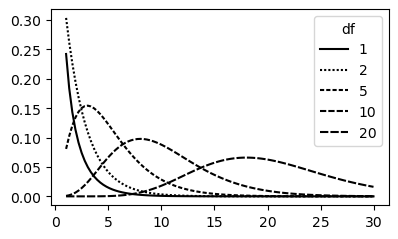

In [25]:
# Calculating Chi-Square distribution  using various degrees of freedom
x = [1 + i * (30 - 1) / 99 for i in range(100)]

chi = pd.DataFrame({
    'x': x,
    'chi_1': stats.chi2.pdf(x, df=1),
    'chi_2': stats.chi2.pdf(x, df=2),
    'chi_5': stats.chi2.pdf(x, df=5),
    'chi_10': stats.chi2.pdf(x, df=10),
    'chi_20': stats.chi2.pdf(x, df=20),
})
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(chi.x, chi.chi_1, color='black', linestyle='-', label='1')
ax.plot(chi.x, chi.chi_2, color='black', linestyle=(0, (1, 1)), label='2')
ax.plot(chi.x, chi.chi_5, color='black', linestyle=(0, (2, 1)), label='5')
ax.plot(chi.x, chi.chi_10, color='black', linestyle=(0, (3, 1)), label='10')
ax.plot(chi.x, chi.chi_20, color='black', linestyle=(0, (4, 1)), label='20')
ax.legend(title='df')

plt.tight_layout()
plt.show()

## Fisher's Exact Test

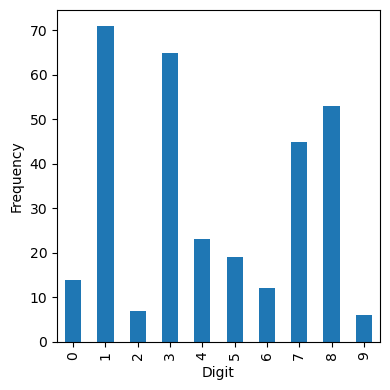

In [26]:
# Load data
imanishi = pd.read_csv('imanishi_data.csv')

# Strip out the leading and trailing whitespance in the columns
imanishi.columns = [c.strip() for c in imanishi.columns]

# PLot the digit and frequency values 
ax = imanishi.plot.bar(x="Digit",
                       y="Frequency",
                       legend=False,
                       figsize=(4,4))
ax.set_xlabel("Digit")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Power and Sample Size

In [27]:
# Calculate the sample size to achieve a 80% power
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size = effect_size,
                              alpha=0.05,
                              power=0.8,
                              alternative="larger")
print("Sample Size: %.3f" % result)

Sample Size: 116602.393


In [28]:
# Calculate the sample size to achieve a 80% power
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, 
                              alpha=0.05, 
                              power=0.8, 
                              alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 5488.408
